# Final Project: Topic Modeling

## Executive Summary: 
In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.

## Importing the Dataset: Trip Advisor Reviews

In [32]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation
import numpy as np # numerical operations

# Text preprocessing and feature extraction
from sklearn.manifold import TSNE  # Required for t-SNE projection
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Preprocessing: 
Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

### Language Filter

In [6]:
# Filter out non-English reviews

# Define a function to identify the language of the text
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

# Apply the language identification function to the 'Review' column and create a new 'Language' column
df['Language'] = df['Review'].apply(do_language_identifying)
print(df['Language'].value_counts())

# Filter the DataFrame to include only English reviews
reviews_en = df[df['Language'] == 'en']

Language
en    20475
fr        6
af        5
nl        2
ro        2
es        1
Name: count, dtype: int64


### Tokenization / Removing Punctuation / Case Normalization

In [7]:
#  Define a regular expression pattern to match words, including those with apostrophes and hyphens
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

# Define a function to tokenize the text for topic modeling
def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

# Apply the tokenization function to the 'Review' column and create a new 'Tokens' column
reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

# Display the tokens for the first review
reviews_en['Tokens'][0]

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [8]:
# Remove stop words from the tokens
list_stop_words = nltk.corpus.stopwords.words("English")

# Define a list of additional stop words specific to hotel reviews
hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',
                    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 
                    'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']

# Extend the list of stop words with the hotel-specific stop words
list_stop_words.extend(hotel_stop_words)

# Remove stop words from the tokens in the 'Tokens' column
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

### Lemmatization

In [9]:
# Lemmatize the tokens in the 'Tokens' column
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

# Display the cleaned tokens for the first review
reviews_en['Tokens'].head()

0    [nice, expensive, parking, good, deal, anniver...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, experience, monaco, seattle, good, n't,...
3    [unique, great, wonderful, monaco, location, e...
4    [great, great, seahawk, game, awesome, downfal...
Name: Tokens, dtype: object

## Vectoring the text data:

#### Vectoring for LDA

In [12]:
# Prepare the data for LDA by joining the tokens back into a single string for each review
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Display the cleaned text for the first few reviews
LDA_data[['Tokens', 'clean_text']].head()

,Tokens,clean_text
0,"[nice, expensive, parking, good, deal, anniver...",nice expensive parking good deal anniversary a...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, experience, monaco, seattle, good, n't,...",nice experience monaco seattle good n't level ...
3,"[unique, great, wonderful, monaco, location, e...",unique great wonderful monaco location excelle...
4,"[great, great, seahawk, game, awesome, downfal...",great great seahawk game awesome downfall view...


In [ ]:
# Define a function to calculate perplexity for different numbers of topics
def perplexity_by_ntopic(data, ntopics, max_df, min_df, max_features):
    """
    Calculate perplexity for different numbers of topics.
    Parameters:
    - data: Document-term matrix (e.g., from CountVectorizer)
    - ntopics: List of numbers of topics to evaluate
    - max_df: Maximum document frequency for term filtering
    - min_df: Minimum document frequency for term filtering
    - max_features: Maximum number of features for term filtering
    Returns:
    - output_df: DataFrame with number of topics and corresponding perplexity scores"""
    
    # Initialize a dictionary to store the number of topics and their corresponding perplexity scores
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    # Loop through each number of topics in the ntopics list
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="batch",
            random_state=0,
            n_jobs=-1
        )

        # Fit the LDA model to the data
        lda.fit(data)
        
        # Append the number of topics and the corresponding perplexity score to the output dictionary
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))

        # Print the current parameter combination and the calculated perplexity score
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated perplexity for {t} topics: {output_dict['Perplexity Score'][-1]}")

    # Convert the output dictionary to a DataFrame for easier analysis    
    output_df = pandas.DataFrame(output_dict)
    
    # Find the index of the minimum perplexity score and retrieve the corresponding number of topics
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
    
    # Return the DataFrame with perplexity scores and the optimal number of topics     
    return (output_df, output_num_topics)

In [43]:
# Define different parameter combinations for CountVectorizer
ngram_ranges = [(1, 1), (1, 2)] 
max_dfs = [0.75, 0.85, 0.95]
min_dfs = [2, 5, 10]
max_feats = [1000, 2000, 3000]

count_vectorizers = []

# Loop through everything including the N-Gram range
for n_range in ngram_ranges:
    for max_df in max_dfs:
        for min_df in min_dfs:
            for max_features in max_feats:
                vectorize = CountVectorizer(
                    max_df=max_df,
                    min_df=min_df,
                    max_features=max_features,
                    ngram_range=n_range
                )
                count_vectorizers.append(vectorize)

### Count Vectorizer Grid Search
According to our research and the examples available in the book, we found that the best word vectorizer for LDA models was `CountVectorizer()`. In this step, we explore different values for a count vectorizer to be used for LDA based on perplexity scores as a starting point for our next exploration.

In [ ]:
# Code commented out to avoid long execution time during testing. Uncomment to run the full analysis.

# # Calculate perplexity for each CountVectorizer and store results in a list of DataFrames
# perplexity_dfs = []
# for cv in count_vectorizers:
#     dtm_cv = cv.fit_transform(LDA_data['clean_text'])
    
#     lda_perplexity, optimal_num_topics = perplexity_by_ntopic(
#         dtm_cv,
#         [3, 4, 5, 6],
#         cv.max_df,
#         cv.min_df,
#         cv.max_features
#     )

#     #  Add the label for 1-word or 2-words to the result dataframe
#     label = "1-word" if cv.ngram_range == (1, 1) else "1 & 2-word"
#     lda_perplexity['Ngram_Type'] = label
    
#     lda_perplexity['Max_Features'] = cv.max_features
#     lda_perplexity['Max_DF'] = cv.max_df
#     lda_perplexity['Min_DF'] = cv.min_df
    
#     perplexity_dfs.append(lda_perplexity)

max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 570.8417718003667
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 572.9017861274805
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 5 topics: 573.6164136320155
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 6 topics: 575.4653528518508
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 907.9734320061139
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 893.715861659488
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 5 topics: 894.9277986207072
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 6 topics: 892.8327565458771
max_df = 0.75, min_df = 2, max_features = 3000 : Calculated perplexity for 3 topics: 1127.8028230671441
max_df = 0.75, min_df = 2, max_features = 3000 : Calculated perplexity fo

KeyError: "['perplexity'] not in index"

In [ ]:
# Uncomment to run the full analysis.

# # Concatenate all the perplexity DataFrames into a single DataFrame for analysis
# perp_concat = pd.concat(perplexity_dfs, ignore_index=True)
# perp_concat.sort_values(by='Perplexity Score', inplace=True)

# # Display the full DataFrame with all rows and columns to analyze the perplexity scores for different parameter combinations
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(perp_concat)

,Number Of Topics,Perplexity Score,Ngram_Type,Max_Features,Max_DF,Min_DF
0,3,570.841772,1-word,1000,0.75,2
24,3,570.841772,1-word,1000,0.75,10
60,3,570.841772,1-word,1000,0.85,10
36,3,570.841772,1-word,1000,0.85,2
96,3,570.841772,1-word,1000,0.95,10
72,3,570.841772,1-word,1000,0.95,2
12,3,571.312805,1-word,1000,0.75,5
48,3,571.312805,1-word,1000,0.85,5
84,3,571.312805,1-word,1000,0.95,5
87,6,572.002295,1-word,1000,0.95,5


#### Summary of the grid search:

* max_features: Selects the number of most common phrases and builds a matrix whit them. This change results in the biggest perplexity changes (impact in the hundreds).

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 940.4003603206078

* ngram_type: Determines whether the model uses only single words or includes two-word phrases. Including bigrams provides much better context for the topics, but it typically results in a moderate increase in the perplexity score (around 10 points)

  Ex:
    
    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 570.8417718003667

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

* ntopics = Number of topics the model is splitting the results to. This carries a slight change to the perplexity score (usually in the single digits)

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 577.5374308791278


* min_df: Represents the minimum number of documents a word or bi-gram must appear in to be included in your model. This parameter seems to have a very minor change on perplexity usually in the single digits

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 5, max_features = 1000 : Calculated perplexity for 3 topics: 584.7858969516453

    max_df = 0.75, min_df = 10, max_features = 1000 : Calculated perplexity for 3 topics: 587.1110544494958


* max_df: Used to filter out words that appear too frequently to be useful for distinguishing between topics. This parameter seems to carry zero weight on the over all perplexity score resulting in no changes

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506
    
    max_df = 0.95, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506


## Models: 
Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Defined Approach:
- Performing grid search on different parameters for the vectorizers in order to select the best combination of parameters + an optimal number of topics.
- Once we select our best combination for the vectorizer, we will explore parameter combinations for the models in order to obtain the best combination and select the best model based on that.

## LDA Exploring

### Selecting our number of topics: Helper Function
Function to explore different number of topics

### LDA Parameters Grid Search (1 word)
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [47]:
# Based on the perplexity analysis, we can select the best parameter combination for CountVectorizer and fit the LDA model with different numbers of topics to find the optimal number of topics.
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=2,          
    max_features=2000,
    ngram_range=(1, 2)
)

# Fit the CountVectorizer to the cleaned text data and transform it into a document-term matrix 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])

# Define different numbers of topics and maximum iterations for LDA model fitting 
max_iter = [10, 20, 30]
selected_num_topics = [4, 5, 6]
lda_models_arr_sword = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

# Loop through each combination of max_iter and num_topics, fit the LDA model, and store the model and its perplexity score in the lda_models_arr_sword dictionary
for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr_sword[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 934.9471350569152
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 930.483804196706
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 925.6557073275311
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 932.5507364535117
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 927.4491966991687
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 920.5289999711537
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 931.7030670834029
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 926.113945408719
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 919.2329360759007


### LDA Parameters Grid Search (2 words)
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [48]:
# Based on the perplexity analysis, we can select the best parameter combination for CountVectorizer and fit the LDA model with different numbers of topics to find the optimal number of topics.
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=2,          
    max_features=2000,
    ngram_range=(2, 2)
)

# Fit the CountVectorizer to the cleaned text data and transform it into a document-term matrix 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])

# Define different numbers of topics and maximum iterations for LDA model fitting 
max_iter = [10, 20, 30]
selected_num_topics = [4, 5, 6]
lda_models_arr_mword = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

# Loop through each combination of max_iter and num_topics, fit the LDA model, and store the model and its perplexity score in the lda_models_arr_mword dictionary
for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr_mword[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 1267.594083765794
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 1317.3921961235171
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 1330.1851968833353
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 1247.4979485895428
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 1293.1849955032849
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 1291.0274208078877
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 1243.6368913517395
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 1284.5569922494342
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 1283.1817164104834


### Interpretability Check: Words and Document Matrices of models

In [50]:
# Define a function to extract the top words for each topic and the most relevant documents for each topic from the fitted LDA model
def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    # Create dictionaries to store the top words and relevant documents for each topic
    W_dict = {}
    H_dict = {}
    
    # Loop through each topic and extract the top words and relevant documents based on the W and H matrices
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values

    # Convert the W and H dictionaries into DataFrames for better visualization and analysis    
    W_df = pd.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pd.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
       
    return (W_df, H_df)

In [52]:
# Set the number of documents and words to extract for each topic
number_docs = 10 
number_words = 15 

# Extract the top words and relevant documents
W_df, H_df = get_topics(
    mod=lda_models_arr_sword[(30, 4)],
    vec=dtm_cv_final,
    names=cv_final.get_feature_names_out(), # Correctly pulls the (1,2) ngrams
    docs=LDA_data['Review'].tolist(),       # Ensures indices match the DTM
    ndocs=number_docs, 
    nwords=number_words
)

# Display the tables
print('*' * 50)
print("Word - Topic Table (Unigrams & Bigrams):")
print('*' * 50)
display(W_df) 

print('\n' + '*' * 50)
print("Document - Topic Table:")
print('*' * 50)
display(H_df)

**************************************************
Word - Topic Table (Unigrams & Bigrams):
**************************************************


,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0239, good restaurant)","(0.0221, beach resort)","(0.0184, metro station)","(0.0129, right heart)"
Word1,"(0.0201, small nice)","(0.0193, reasonable rate)","(0.0159, good restaurant)","(0.0099, dining option)"
Word2,"(0.0197, large clean)","(0.016, french fry)","(0.0132, good experience)","(0.0098, small nice)"
Word3,"(0.0157, good experience)","(0.0157, parking free)","(0.0108, beautiful great)","(0.0086, key card)"
Word4,"(0.0147, best western)","(0.0136, good restaurant)","(0.0105, large clean)","(0.0071, beautiful great)"
Word5,"(0.0114, check out)","(0.0129, good experience)","(0.01, bad service)","(0.0064, bar food)"
Word6,"(0.0108, family friend)","(0.0106, reception desk)","(0.0088, service menu)","(0.0062, balcony view)"
Word7,"(0.0104, great kid)","(0.0088, offer free)","(0.0081, beach gorgeous)","(0.0057, grand paradise)"
Word8,"(0.0099, friendly professional)","(0.008, metro station)","(0.0081, check out)","(0.0057, pleasant helpful)"
Word9,"(0.0088, walk block)","(0.0075, bavaro princess)","(0.008, free internet)","(0.0056, ground beautiful)"



**************************************************
Document - Topic Table:
**************************************************


,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.9572, positives negatives breezes jamaica t...","(0.96, great staff beautiful setting just came...","(0.9508, respite noise bustle stayed san franc...","(0.9622, swiss delight 6 3 couples spent 5 nig..."
Doc1,"(0.9542, read staying paradisus palma real rea...","(0.9573, lovely hotel great staff good minor c...","(0.9471, good choice san francisco just union ...","(0.9604, ok place stayed hard rock hotel 23-26..."
Doc2,"(0.9533, excellent value great location family...","(0.9551, met expectations, currently staying 3...","(0.9461, worst hotel n't expecting luxury hote...","(0.96, excellent first-time experience wingate..."
Doc3,"(0.9489, great haven husband king room floor 6...","(0.9535, brown, stayed mh end august, booked r...","(0.9455, fantastic, stayed chancellor 5 nights...","(0.9563, relaxing place just come iberostar pu..."
Doc4,"(0.945, great stay stayed 3 nights mid april 1...","(0.9534, superb hotel went visit hong kong 07 ...","(0.9451, comfy enjoyable 5nt stay 2 rooms fami...","(0.9507, unforgettable hotel david hotels stay..."
Doc5,"(0.9449, 5 star service attitude family 5 3 sm...","(0.9527, enjoyable reading reviews website reg...","(0.9441, great vacation just returned place, p...","(0.9499, honeymoon heaven, husband just return..."
Doc6,"(0.9433, quiet peaceful getaway hotel resort i...","(0.951, excellent location great service, fami...","(0.943, great stay great hotel just returned h...","(0.9498, outstanding got residence inn priceli..."
Doc7,"(0.9428, good value good location stayed end a...","(0.9501, gem hotel barcelona, stayed partner s...","(0.9423, good location stayed 2 nights, room c...","(0.9498, great place early flights stayed frie..."
Doc8,"(0.9405, fantastic hotel great lodation, staye...","(0.9498, exceedingly poor service mildewed roo...","(0.942, n't bother looking rest, just returned...","(0.9481, hated hilton times square location go..."
Doc9,"(0.9399, fab hotel moment arrive intercontinen...","(0.9496, tall tales singapore 1998 visited hot...","(0.9399, refined got great deal internet 40 ad...","(0.9464, cool hotel, stayed 3 nights una vitto..."


In [53]:
# Prepare the data for pyLDAvis visualization by creating a balanced dataset of negative/neutral and positive reviews
neg_neutral = reviews_en[reviews_en['Rating'] <= 3]
positive = reviews_en[reviews_en['Rating'] > 3]
positive_sampled = positive.sample(n=len(neg_neutral), random_state=42)
balanced_df = pd.concat([neg_neutral, positive_sampled]).reset_index(drop=True)
balanced_df['clean_text'] = balanced_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Re-vectorize and Fit (Your existing logic)
bi_cv = CountVectorizer(max_df=0.85, min_df=5, max_features=2000, stop_words=hotel_stop_words, ngram_range=(2, 2))
dtm_bi = bi_cv.fit_transform(balanced_df['clean_text'])
final_lda_bi = LatentDirichletAllocation(n_components=4, random_state=42, n_jobs=-1)
final_lda_bi.fit(dtm_bi)

# Extract components manually for the visualizer
def format_data_for_vis(model, dtm, vectorizer):
    return {
        'topic_term_dists': model.components_ / model.components_.sum(axis=1)[:, np.newaxis],
        'doc_topic_dists': model.transform(dtm),
        'doc_lengths': dtm.sum(axis=1).getA1(),
        'vocab': vectorizer.get_feature_names_out(),
        'term_frequency': dtm.sum(axis=0).getA1()
    }

data = format_data_for_vis(final_lda_bi, dtm_bi, bi_cv)

# Prepare and Display
lda_display = pyLDAvis.prepare(**data, sort_topics=False)
pyLDAvis.display(lda_display)

In [73]:
# --- Data Preparation ---
neg_neutral = reviews_en[reviews_en['Rating'] <= 3]
positive = reviews_en[reviews_en['Rating'] > 3]
positive_sampled = positive.sample(n=len(neg_neutral), random_state=42)
balanced_df = pd.concat([neg_neutral, positive_sampled]).reset_index(drop=True)
balanced_df['clean_text'] = balanced_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

# --- Vectorization & Modeling (Bi-grams, K=4) ---
bi_cv = CountVectorizer(max_df=0.85, min_df=5, max_features=2000, stop_words=hotel_stop_words, ngram_range=(2, 2))
dtm_bi = bi_cv.fit_transform(balanced_df['clean_text'])

final_lda_bi = LatentDirichletAllocation(n_components=4, random_state=42, n_jobs=-1)
final_lda_bi.fit(dtm_bi)

# --- Manual Data Extraction for Visualizer ---
def format_data_for_vis(model, dtm, vectorizer):
    return {
        'topic_term_dists': model.components_ / model.components_.sum(axis=1)[:, np.newaxis],
        'doc_topic_dists': model.transform(dtm),
        'doc_lengths': dtm.sum(axis=1).getA1(),
        'vocab': vectorizer.get_feature_names_out(),
        'term_frequency': dtm.sum(axis=0).getA1()
    }

data = format_data_for_vis(final_lda_bi, dtm_bi, bi_cv)

# --- Visualization with t-SNE ---
# We define a lambda to ensure pyLDAvis uses the sklearn TSNE implementation properly
lda_display = pyLDAvis.prepare(
    **data, 
    sort_topics=False, 
    mds=lambda dists: TSNE(n_components=2, perplexity=2, random_state=42, init='pca').fit_transform(dists)
)

pyLDAvis.display(lda_display)

In [56]:
# The matrix 'dtm_bi' has 10,786 rows (from balanced_df)
lda_bi_topic_results = final_lda_bi.transform(dtm_bi)

# FIX: Assign the topics to balanced_df, not LDA_data
balanced_df['Topic'] = lda_bi_topic_results.argmax(axis=1)

# Reorder columns using balanced_df
balanced_results = balanced_df[['Review', 'Rating', 'Topic', 'Tokens']]

# See the average rating for each topic
print("Average Rating per Topic:")
print(balanced_results.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print("\nReview Count per Topic:")
print(balanced_results['Topic'].value_counts())

Average Rating per Topic:
Topic
0    3.106154
1    3.102627
2    3.916687
3    2.905072
Name: Rating, dtype: float64

Review Count per Topic:
Topic
2    4093
1    2436
3    2307
0    1950
Name: count, dtype: int64


### LDA Visualizations: T-SNE

In [71]:
# Updated function to handle the new parameter naming convention
def plot_tsne(data, threshold, perplexity=30, n_iter=1000):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]
   
    # fit tsne model
    # FIX: Changed n_iter to max_iter
    tsne = sklearn.manifold.TSNE(
        n_components=2,
        verbose=0,
        random_state=0,
        angle=0.5,
        init='pca',
        perplexity=perplexity,
        max_iter=n_iter # Renamed this keyword argument
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)
   
    # rest of the function remains the same...
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())
   
    print("LENGTH:\n{}\n".format(len(most_prob_topic)))
 
    unique, counts = numpy.unique(
        numpy.array(most_prob_topic),
        return_counts=True
    )
 
    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))
   
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
 
    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0],
            y=tsne_fit[indices, 1],
            s=0.5,
            c=color_list[i],
            label='Topic' + str(i),
            alpha=0.25
        )
 
    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
5420

COUNTS:
[[   0  627]
 [   1 1683]
 [   2 2194]
 [   3  916]]



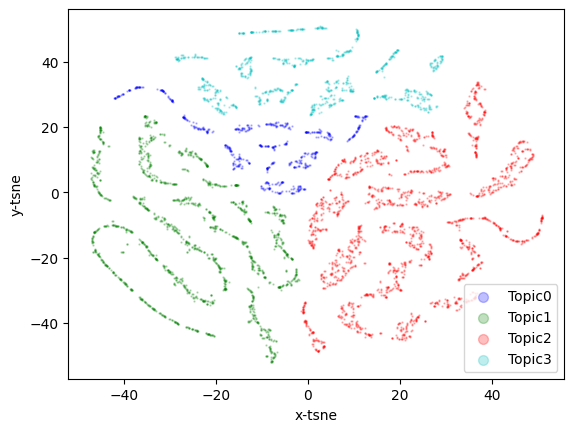

In [72]:
plot_tsne(data=lda_bi_topic_results, threshold=0.75, perplexity=15, n_iter=500)

LENGTH:
4795

COUNTS:
[[   0 1771]
 [   1 1112]
 [   2  807]
 [   3  676]
 [   4  362]
 [   5   67]]



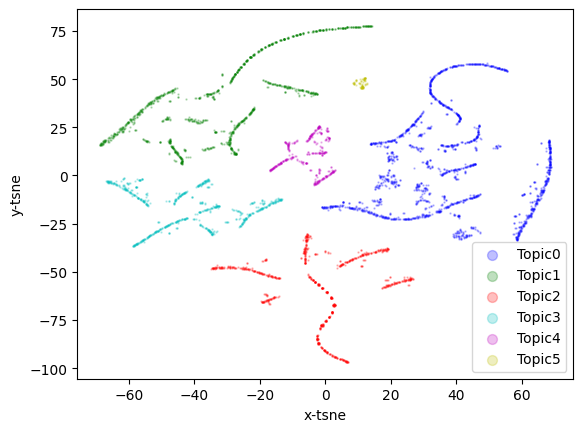

In [ ]:
lda_transform = best_lda.transform(dtm_cv_final)
plot_tsne(data=lda_transform, threshold=0.75)

### Vectorization for NMF
### Hyperparameter Stack:
.....

In [107]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [108]:
def nmf_reconstruction_error(data, ntopics, max_df, min_df, max_features):  # function to calculate reconstruction error for NMF model with different numbers of topics and vectorizer parameters
    nmf_output_dict = {
        "Number Of Topics": [], 
        "Reconstruction Error": []
    }
    
    for t in ntopics:   # iterate over the list of topic numbers
        nmf = sklearn.decomposition.NMF(
            n_components=t,
            solver='cd',
            random_state=0
        )
        nmf.fit(data)
        
        nmf_output_dict["Number Of Topics"].append(t)
        nmf_output_dict["Reconstruction Error"].append(nmf.reconstruction_err_)
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated reconstruction error for {t} topics: {nmf_output_dict['Reconstruction Error'][-1]}")
        
    output_df = pandas.DataFrame(nmf_output_dict)   # convert the output dictionary to a pandas dataframe for easier analysis
    
    index_min_perplexity = output_df["Reconstruction Error"].idxmin()   # get the index of the minimum reconstruction error
    output_num_topics = output_df.loc[
        index_min_perplexity,
        "Number Of Topics"
    ]
        
    return (output_df, output_num_topics)

In [109]:
tfidf_number_features = 2000
tfidf_number_docs = 10
tfidf_number_words = 10

tfidf_max_dfs = [0.85]
tfidf_min_dfs = [2, 5, 10]
tfidf_max_feats = [2000]

tfidf_vectorizers = [] 
for max_df in tfidf_max_dfs:
    for min_df in tfidf_min_dfs:
        for max_features in tfidf_max_feats:
            tfidf_vectorizer = TfidfVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features,
                stop_words=hotel_stop_words,
                ngram_range=(2, 2)
            )
            tfidf_vectorizers.append(tfidf_vectorizer)

In [110]:
import warnings
warnings.filterwarnings("ignore")
tfidf_perplexity_dfs = []
for tfidf_v in tfidf_vectorizers:
    dtm_cv = tfidf_v.fit_transform(nmf_data['clean_text'])

    nmf_perplexity, optimal_num_topics = nmf_reconstruction_error(
        dtm_cv,
        [3, 4, 5, 6],
        tfidf_v.max_df,
        tfidf_v.min_df,
        tfidf_v.max_features
    )

    nmf_perplexity['Max_Features'] = tfidf_v.max_features
    nmf_perplexity['Max_DF'] = tfidf_v.max_df
    nmf_perplexity['Min_DF'] = tfidf_v.min_df
    tfidf_perplexity_dfs.append(nmf_perplexity)

max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 3 topics: 140.82021074870954
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 4 topics: 140.4866275360383
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 5 topics: 140.1746758772331
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 6 topics: 139.92716596427505
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 3 topics: 140.82005085506813
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 4 topics: 140.4860427572602
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 5 topics: 140.17405356886894
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 6 topics: 139.92623211605317
max_df = 0.85, min_df = 10, max_features = 2000 : Calculated reconstruction error for 3 top

In [111]:
def plot_tsne(data, threshold):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold    #get boolean index of rows where max topic probability meets threshold
    lda_transform_filt = data[index_meet_threshold]
    
    # fit tsne model
    # x-d -> 2-d, x = number of topics
    tsne = sklearn.manifold.TSNE(   # create TSNE model with specified parameters
        n_components=2,
        perplexity=50, 
        verbose=0, 
        random_state=0, 
        angle=0.5, 
        init='pca'
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)   # fit and transform the filtered data using the TSNE model
    
    # most probable topic for each headline
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):  # iterate over each row in the filtered data
        most_prob_topic.append(lda_transform_filt[i].argmax())  # append the index of the maximum topic probability for each row to the most_prob_topic list
    
    print("LENGTH:\n{}\n".format(len(most_prob_topic))) # print the length of the most_prob_topic list to verify it matches the number of rows in the filtered data

    unique, counts = numpy.unique(  # get unique topic indices and their counts
        numpy.array(most_prob_topic), 
        return_counts=True
    )

    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))    # print the unique topic indices and their counts in a readable format
    
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    for i in list(set(most_prob_topic)):    # iterate over unique topic indices
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]# get indices of rows where the most probable topic matches the current topic index
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0], 
            y=tsne_fit[indices, 1], 
            s=0.5, 
            c=color_list[i], 
            label='Topic' + str(i),
            alpha=0.25
        )

    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
20475

COUNTS:
[[    0 10013]
 [    1  6207]
 [    2  2256]
 [    3  1999]]



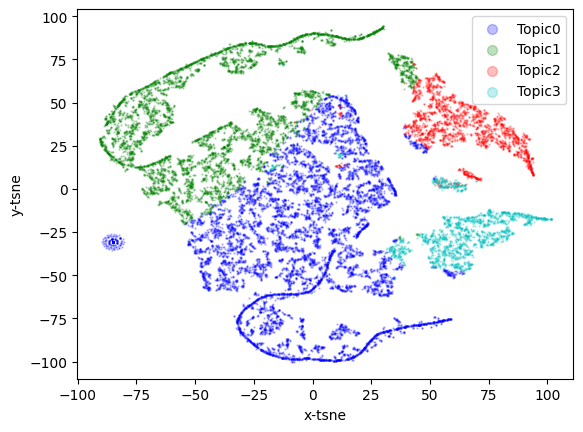

In [114]:

nmf = sklearn.decomposition.NMF(
    n_components=4,
    solver='cd',
    random_state=0,
)

nmf_transformed = nmf.fit_transform(tfidf_vectorizers[1].fit_transform(nmf_data['clean_text']))

plot_tsne(data=nmf_transformed, threshold=0)

In [115]:
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

nmf_transformed = []

for i in range(len(tfidf_vectorizers)):
    print(f"--- Visualizing Model {i+1} ---")
    
    # 1. Vectorize text with the current vectorizer in your list
    current_dtm = tfidf_vectorizers[i].fit_transform(nmf_data['clean_text'])
    
    # 2. Instantiate and Fit a fresh NMF model for this specific vectorizer
    nmf_model = NMF(n_components=4, solver='cd', random_state=0)
    weights = nmf_model.fit_transform(current_dtm)
    
    # 3. Save the results to your list
    nmf_transformed.append(weights)
    
    # 4. Generate the plot
    # If plot_tsne doesn't call plt.show(), we call it here
    plot_tsne(data=weights, threshold=0)
    
    # 5. Force the plot to render for THIS model before the next iteration starts
    plt.title(f"NMF t-SNE Plot: Model {i+1}")
    plt.show()

--- Visualizing Model 1 ---


KeyboardInterrupt: 

In [116]:

def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_ # shape: (n_topics, n_words)
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]    # normalize rows to sum to 1
    # topic to document matrix
    H = mod.transform(vec)  # shape: (n_docs, n_topics)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):  # iterate over topics
        topic = "Topic{}".format(tpc_idx)   # create topic name
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]    # get indices of top n words for this topic
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]   # create list of tuples (value, word) for top n words
        W_dict[topic] = W_names_values  # assign list of tuples to topic in W_dict
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]   # get indices of top n documents for this topic
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j])   # create list of tuples (value, document) for top n documents
            for j in H_indices
        ]
        H_dict[topic] = H_names_values  # assign list of tuples to topic in H_dict
        
    W_df = pandas.DataFrame(    # create dataframe from W_dict with word names as index
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pandas.DataFrame(    # create dataframe from H_dict with document names as index
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [117]:
wdf, hdf, = get_topics(
    mod=nmf, 
    vec=tfidf_vectorizers[0].fit_transform(nmf_data['clean_text']), # fit_transform the clean text data using the first TF-IDF vectorizer
    names=tfidf_vectorizers[0].get_feature_names_out(), 
    docs=nmf_data['Review'].tolist(), 
    ndocs=tfidf_number_docs, 
    nwords=tfidf_number_words
)

In [118]:
print(wdf)

                             Topic0                      Topic1  \
Word0        (0.0129, mixed review)   (0.0239, quality service)   
Word1       (0.0121, staff helpful)       (0.0137, santa maria)   
Word2          (0.0108, wall paper)         (0.0074, food food)   
Word3            (0.0092, th floor)       (0.0065, making sure)   
Word4          (0.0082, good value)         (0.0064, old world)   
Word5        (0.008, good location)          (0.006, pool good)   
Word6         (0.0072, value price)  (0.0056, language barrier)   
Word7       (0.0061, train station)       (0.0055, beach ocean)   
Word8        (0.0051, nice balcony)    (0.0052, pool beautiful)   
Word9  (0.0049, highly recommended)         (0.0048, beach bar)   

                               Topic2                        Topic3  
Word0        (0.1297, staff friendly)         (0.1731, great loved)  
Word1        (0.1002, friendly great)     (0.0381, location lovely)  
Word2        (0.0134, clean spacious)       (0.0221,

In [ ]:
print(hdf)  

                                                 Topic0  \
Doc0  (0.072, great hotel stayed nights april 08. gr...   
Doc1  (0.0656, good value berlin, stayed hotel octob...   
Doc2  (0.0656, great base seeing bejing stayed hotel...   
Doc3  (0.0646, perfectly situated hotel stayed hotel...   
Doc4  (0.0608, good hotel needing upgrade spent 2 ni...   
Doc5  (0.0599, nice hotel location questionable stay...   
Doc6  (0.0597, great hotel, just returned 3 night st...   
Doc7  (0.0595, lovely hotel, hotel nice hotel, booke...   
Doc8  (0.0591, beautiful great hotel 25 day stay ita...   
Doc9  (0.059, great hotel stayed hotel 41 times squa...   

                                                 Topic1  \
Doc0  (0.1959, talking hurricane, visited secrets ex...   
Doc1  (0.1959, fabulous dreams, loved incredible tri...   
Doc2  (0.1959, vacation paradise, family recently re...   
Doc3  (0.1959, worst vacations thanks resort, n't kn...   
Doc4  (0.1959, beware parasites beware travellers, j...

## Discussion: 
For the best LDA and NMF models, present again the perplexity for each, and display the word-topic and document-topic tables. For your best LDA model, create a biplot visualization using the pyLDAvis package and a t-SNE visualization to explore document-topic relationships in lower-dimensional space. Experiment with values of the relevance metric and be prepared to demonstrate this to your instructor. Write a clear description, in your own words, of the abstract topics found by each model and present this information neatly. Discuss which model has done the best job of identifying topics for your use case and justify this by referring to the analysis and visualizations.
### LDA Visualizations: Biplot